## Import Libraries



In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Loading Dataset

In [35]:
df = pd.read_csv('ford_car_dataset.csv')

In [36]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,145,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,145,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,145,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145,61.4,1.0


In [37]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2
17965,Focus,2015,8299,Manual,5007,Petrol,22,57.7,1.0


In [38]:
df.shape

(17966, 9)

In [39]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [41]:
df.columns.tolist()

['model',
 'year',
 'price',
 'transmission',
 'mileage',
 'fuelType',
 'tax',
 'mpg',
 'engineSize']

In [42]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows: ",duplicate_count)

Number of duplicate rows:  154


In [43]:
df_clean = df.drop_duplicates()

In [44]:
df_clean.duplicated().sum()

np.int64(0)

In [45]:
df_clean.shape

(17812, 9)

In [46]:
df_clean.describe()

,year,price,mileage,tax,mpg,engineSize
count,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000
mean,2016.862396,12269.556310,23381.146362,113.315012,57.908696,1.350623
std,2.052039,4736.285417,19419.011045,62.034603,10.132696,0.432581
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,10000.000000,30.000000,52.300000,1.000000
50%,2017.000000,11288.000000,18277.000000,145.000000,58.900000,1.200000
75%,2018.000000,15295.000000,31098.500000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [47]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [48]:
print(numerical_cols)

['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']


In [49]:
print(categorical_cols)

['model', 'transmission', 'fuelType']


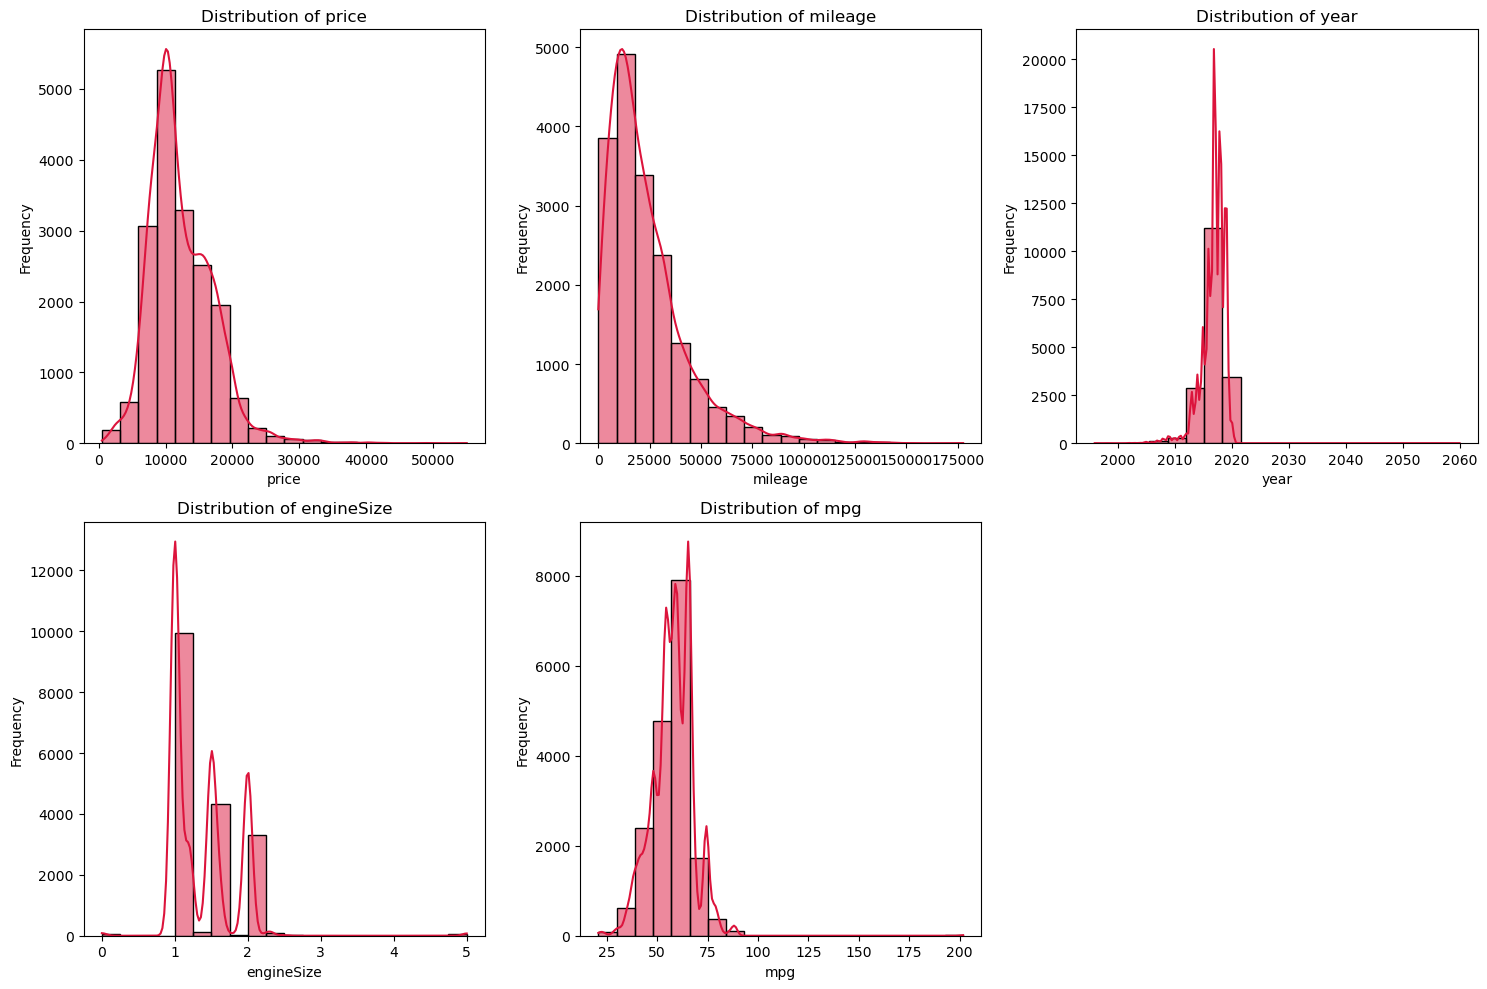

In [50]:
def display_histograms(dataframe):
    target_columns = ["price", "mileage", "year", "engineSize", "mpg"]

    plt.figure(figsize=(15, 10))

    for i, column_name in enumerate(target_columns, 1):
        plt.subplot(2, 3, i)
        sns.histplot(dataframe[column_name], bins=20, kde=True, color="crimson").set_title(f"Distribution of {column_name}")
        plt.xlabel(column_name)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

display_histograms(df)

C:\Users\OMKAR\AppData\Local\Temp\ipykernel_30992\3393569977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x= col, order= df[col].value_counts().index, palette='viridis' )
C:\Users\OMKAR\AppData\Local\Temp\ipykernel_30992\3393569977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x= col, order= df[col].value_counts().index, palette='viridis' )
C:\Users\OMKAR\AppData\Local\Temp\ipykernel_30992\3393569977.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


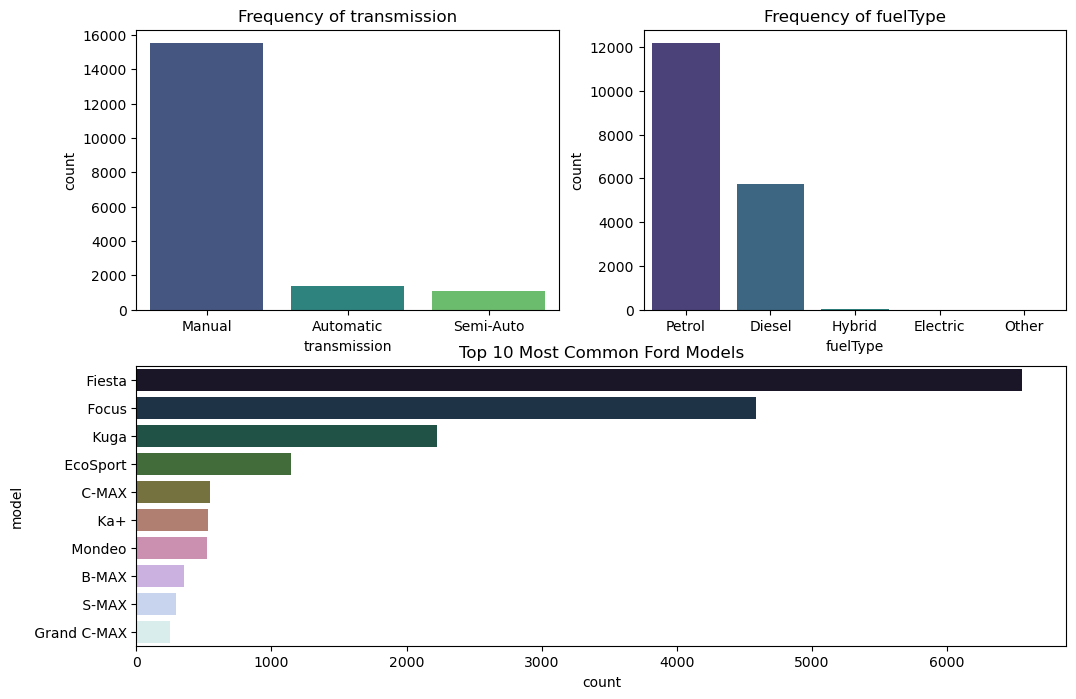

In [51]:
plt.figure(figsize=(12,8))

for i , col in enumerate(["transmission", "fuelType"], 1):
  plt.subplot(2,2,i)
  sns.countplot(data= df, x= col, order= df[col].value_counts().index, palette='viridis' )
  plt.title(f'Frequency of {col}')

plt.subplot(2,2, (3,4))
sns.countplot(
    data=df, y= 'model',
    order = df["model"].value_counts().head(10).index,
    palette="cubehelix"
)
plt.title('Top 10 Most Common Ford Models')
plt.show()

In [52]:
df_corr = df.corr(numeric_only=True)

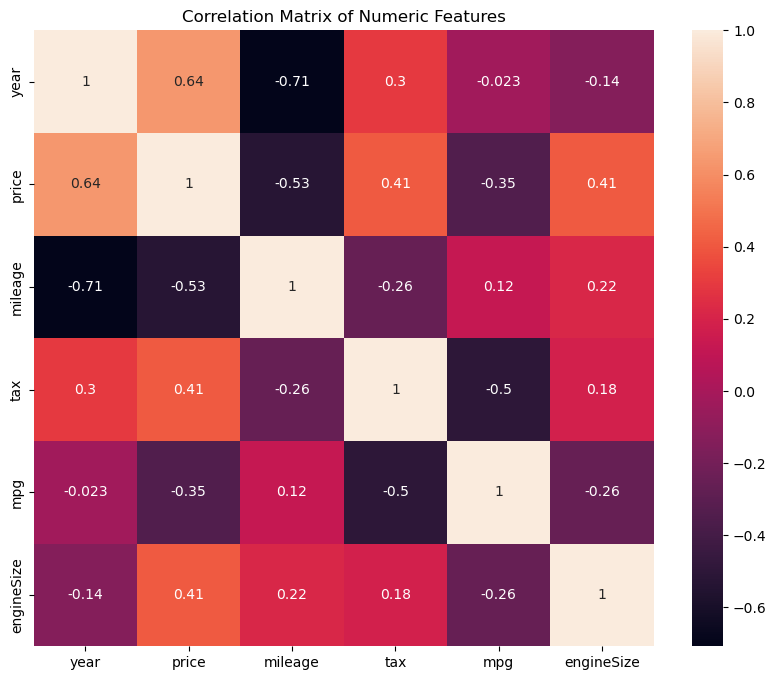

In [53]:
plt.figure(figsize=(10,8))

sns.heatmap(df_corr, annot=True)
plt.title("Correlation Matrix of Numeric Features")

plt.show()

In [54]:
print(categorical_cols)

['model', 'transmission', 'fuelType']


In [55]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, dtype=int, drop_first=True)
df_encoded.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57.7,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,14000,9083,150,57.7,1.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,13000,12456,150,57.7,1.0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,17500,10460,145,40.3,1.5,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,2019,16500,1482,145,48.7,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [56]:
from sklearn.preprocessing import StandardScaler

numeric_features = ["year", "mileage", "tax", "mpg", "engineSize"]

sc = StandardScaler()

df_scaled = df_encoded.copy()
df_scaled[numeric_features] = sc.fit_transform(df_encoded[numeric_features])

In [57]:
df_scaled

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,12000,-0.380998,0.591358,-0.020442,-0.811386,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,14000,-0.733359,0.591358,-0.020442,-0.811386,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,13000,-0.560132,0.591358,-0.020442,-0.811386,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,17500,-0.662640,0.510727,-1.738890,0.345070,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,16500,-1.123724,0.510727,-0.909294,-0.811386,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,8999,-0.342172,0.591358,-1.067312,0.113779,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.398088,7499,0.890398,-1.343791,-0.020442,-0.811386,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.910349,9999,-0.839822,-1.505053,0.927668,0.576362,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.552866,8299,-0.942690,0.510727,-0.020442,-0.348804,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [58]:
X = df_scaled.drop(columns=['price'])
y = df_scaled['price']

print("X shape: ",X.shape)
print("y shape: ",y.shape)

X shape:  (17966, 34)
y shape:  (17966,)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
print("X_train ", X_train.shape)
print("X_test ", X_test.shape)

X_train  (14372, 34)
X_test  (3594, 34)


In [61]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [62]:
y_pred = model.predict(X_test)
y_pred[:10]

array([ 6644.59418325,  9190.94182499,  9815.67023063,  3820.16575035,
        2681.71424617, 16591.34640069, 28710.59207711, 12185.099886  ,
       11553.5791046 , 16796.94074505])

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2: ", r2)

MAE:  1374.8110353356635
MSE:  3454991.9817439797
RMSE:  1858.7608726632857
R2:  0.8458422267142565


In [64]:
import joblib

In [65]:
x = df.drop(columns=['price'])

In [66]:
joblib.dump(model, "./LR_ford_car.pkl" )
joblib.dump(sc, "./scaler.pkl" )
joblib.dump(x, "./columns.pkl" )


['./columns.pkl']